### Solar System Live
#### Plot planets around Sun
Watch where planets are around Sun
#### Get Geocentric positions
The Sun, the planets, the nano planets, our Moon and 1 Centaur


In [ ]:
import matplotlib.pyplot as plt
# import math
import time
import datetime
import helio_solarsystem
# import planetview
# from libraries.planetview import solarsystem

In [ ]:
print(helio_solarsystem.__version__)

0.1.8


#### No need to edit any variable to watch Solar System Live
* Editing date elements below can output positions for the given time
* Edit date elements below if you wish to see where planets will be or where they have been

In [17]:
for i in range(10):
    now    = datetime.datetime.utcnow()
    now    = datetime.datetime.now(datetime.timezone.utc)
    year   = now.year
    month  = now.month
    day    = now.day
    hour   = now.hour
    minute = now.minute
    second = now.second
    # As this is UTC time we set UT to 0
    UT     = 0
    # if (datetime.datetime.now(datetime.timezone.utc).dst())==None:
    #     dst=0
    # else:
    #     dst=1
    dst = 1

    print(year, month, day, hour, minute, second, UT, dst)
    time.sleep(1)

/tmp/ipykernel_8557/940621167.py:2: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  now    = datetime.datetime.utcnow()


2026 9 9 13 26 39 0 1
2026 9 9 13 26 40 0 1
2026 9 9 13 26 41 0 1
2026 9 9 13 26 42 0 1
2026 9 9 13 26 43 0 1
2026 9 9 13 26 44 0 1
2026 9 9 13 26 45 0 1
2026 9 9 13 26 46 0 1
2026 9 9 13 26 47 0 1
2026 9 9 13 26 48 0 1


In [18]:
# planet position output be in horizontal coordinates (longitude, latitude, distance from sun in AU)
view='horizontal'

In [ ]:
H = helio_solarsystem.Heliocentric(year=year, month=month, day=day, hour=hour, minute=minute, 
                         UT=UT, dst=dst, view=view, precession=True )

In [20]:
planets=H.planets()
distances=[]
print('Planet', '   \t','Longitude', '  \t','Latitude', '   \t','Distance')
print('-------------------------------------------------------------------')
for key in planets:
    distances.append(planets[key][2])
    elements = planets[key]
    print(key, '   \t',round(elements[0],2), '   \t',round(elements[1],2), '   \t',round(elements[2],2))
print()
print('Distance is in AU')

Planet    	 Longitude   	 Latitude    	 Distance
-------------------------------------------------------------------
Mercury    	 205.12    	 2.77    	 0.42
Venus    	 319.43    	 -3.02    	 0.73
Earth    	 346.48    	 0.0    	 1.01
Mars    	 74.41    	 0.78    	 1.53
Jupiter    	 129.41    	 0.63    	 5.3
Saturn    	 10.06    	 -2.42    	 9.46
Uranus    	 62.43    	 -0.15    	 19.43
Neptune    	 2.51    	 -1.37    	 29.86
Pluto    	 304.11    	 -4.21    	 35.55
Ceres    	 78.98    	 -0.18    	 2.69
Chiron    	 27.21    	 0.19    	 18.23
Eris    	 24.45    	 -10.42    	 95.44

Distance is in AU


In [ ]:
Hr = helio_solarsystem.Heliocentric(year=year, month=month, day=day, hour=hour, minute=minute, 
                         UT=UT, dst=dst, view='rectangular', precession=True )
planetspositionsHrect=Hr.planets()
# planetspositionsHrect

In [22]:
forplot=[]
planetname=[]
for key in planetspositionsHrect:
    planetname.append(key)
    forplot.append(   planetspositionsHrect[key] )

In [23]:
planetspositionsHrect

{'Mercury': (-0.383204984307509, -0.1796915186218843, 0.020447710681122066),
 'Venus': (0.5523457817797468, -0.4729438961160272, -0.038393583828671494),
 'Earth': (0.9793252036632087, -0.2354789991689043, 0),
 'Mars': (0.411494051080294, 1.4743976908097363, 0.020902270330450293),
 'Jupiter': (-3.3642217228162004, 4.093946892486386, 0.05851985837838217),
 'Saturn': (9.30997588902883, 1.6509020941201362, -0.3990612709507269),
 'Uranus': (8.992092465105681, 17.221221546254654, -0.05157586461373254),
 'Neptune': (29.827466264172006, 1.310103166102426, -0.7141085252977737),
 'Pluto': (19.88204973403157, -29.354554398983037, -2.6096250526663622),
 'Ceres': (0.5136840896255533, 2.6385409619108535, -0.008389215548584914),
 'Chiron': (16.214951368245185, 8.335992103610343, 0.061473560184595745),
 'Eris': (85.44680637277351, 38.845925571871554, -17.26441153197245)}

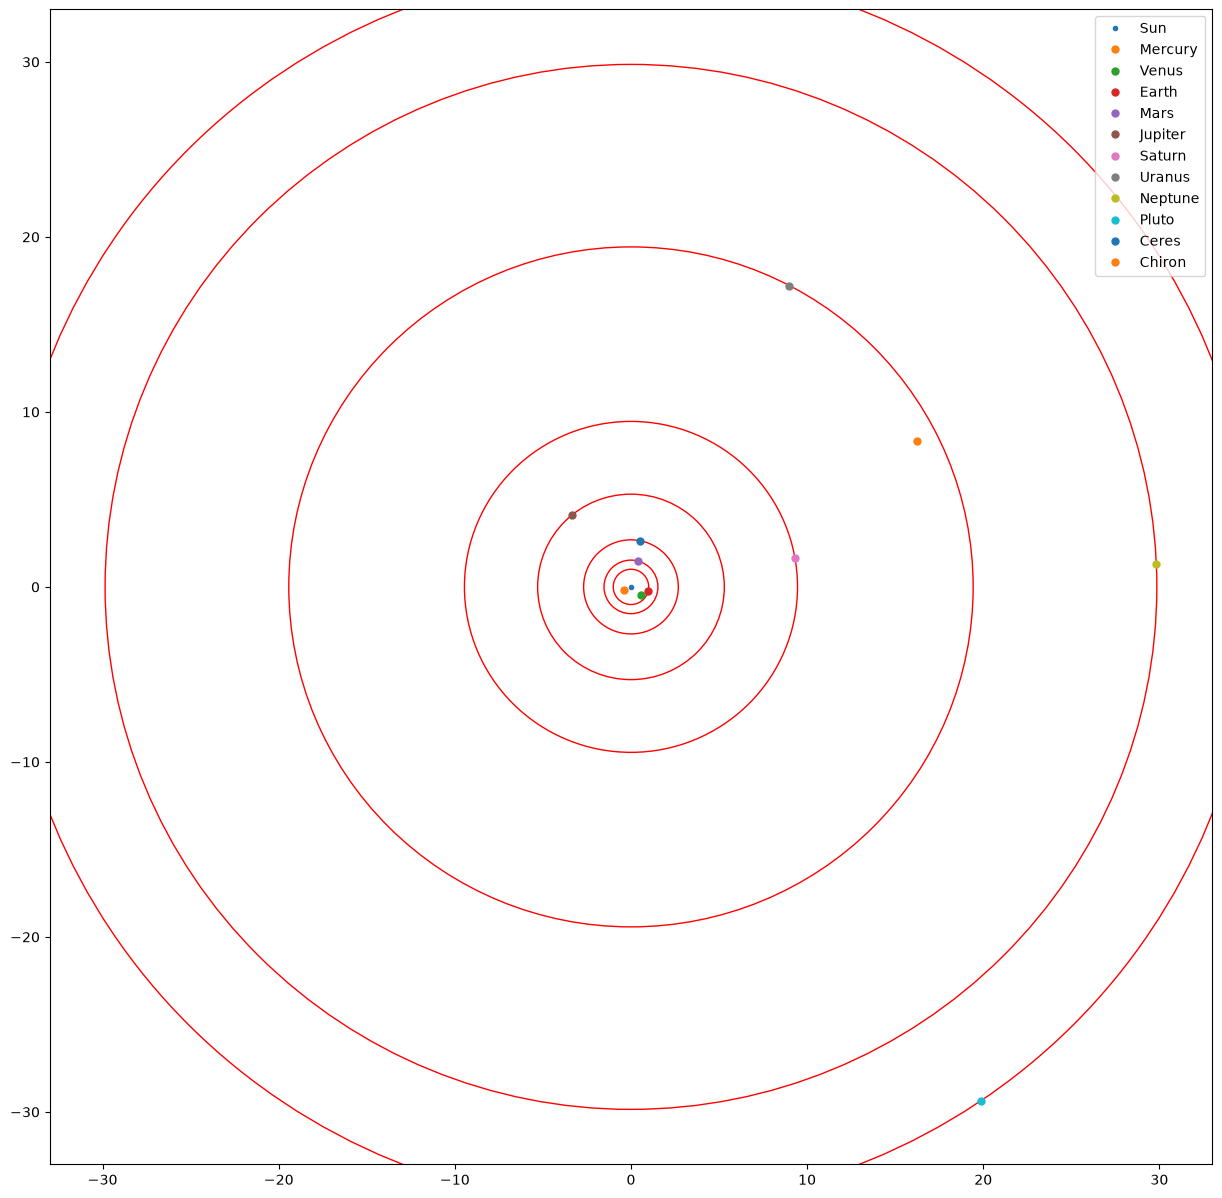

In [24]:
plt.figure(figsize=(15,15))
ax = plt.gca()
ax.cla() # clear things for fresh plot
# ax.set_xlim((-6, 6))
# ax.set_ylim((-6, 6))
ax.set_xlim((-33, 33))
ax.set_ylim((-33, 33))
a=0.5
ax.plot(0,0,'.', label='Sun') 
for i in range(11):
    ax.plot(forplot[i][0] , forplot[i][1] ,'.', markersize=10, label=planetname[i]) 
    if (i >1) & (i < 10):
        ax.add_artist(plt.Circle((0, 0), ((abs(forplot[i][0])**2+abs(forplot[i][1])**2)**0.5), color='r', fill=False))
ax.legend()
plt.show()

In [25]:
def signpower(num, power=0.5):
    sign=1. if num>=0 else -1.
    return (sign*abs(num**power))
signpower(5, 0.5), signpower(-5, 0.5)

(2.23606797749979, -2.23606797749979)

In [26]:
import math
forplot=[]
planetname=[]
for key in planetspositionsHrect:
    planetname.append(key)
#     forplot.append(   planetspositionsHrect[key] )
    forplot.append(   [signpower(x, 0.7) for x in planetspositionsHrect[key]] )
# forplot    

In [27]:
for i, key in enumerate(planetspositionsHrect):
    print(key,forplot[i])

Mercury [-0.510977532153692, -0.30072484196505317, 0.06568274343947939]
Venus [0.6600057652398584, -0.5920613857837881, -0.1020894953704058]
Earth [0.9854823536605164, -0.3633846072529696, 0.0]
Mars [0.5370991842118171, 1.312291299358587, 0.06670147259875978]
Jupiter [-2.3378639142065594, 2.6822517865101396, 0.13712362524169927]
Saturn [4.767206772262091, 1.4203812245228002, -0.5256875685698268]
Uranus [4.6526730472025015, 7.332376683205121, -0.1255198934816667]
Neptune [10.770390611795557, 1.2081304967674888, -0.7900143000275451]
Pluto [8.108169315319692, -10.650569839374961, -1.9570624267688985]
Ceres [0.6273173225066081, 1.9722169570315071, -0.03520504851718733]
Chiron [7.0297673992684055, 4.412351540243694, 0.14193250112040148]
Eris [22.50023658961681, 12.958115051644299, -7.3452443166995725]


In [28]:
import matplotlib.colors as mcolors
# matplotlib.plot_colortable(mcolors.TABLEAU_COLORS, ncols=2, sort_colors=False)
# mcolors.CSS4_COLORS

In [29]:
planet_colors={
 'Mercury': 'silver',
 'Venus':'orange' ,
 'Earth': 'lightskyblue',
 'Mars': 'orangered',
 'Jupiter': 'brown',
 'Saturn':'tan' ,
 'Uranus':'skyblue' ,
 'Neptune': 'blue',
 'Pluto': 'darkblue',
 'Ceres': 'wheat',
 'Chiron': 'greenyellow',
 'Eris':'darkviolet'}

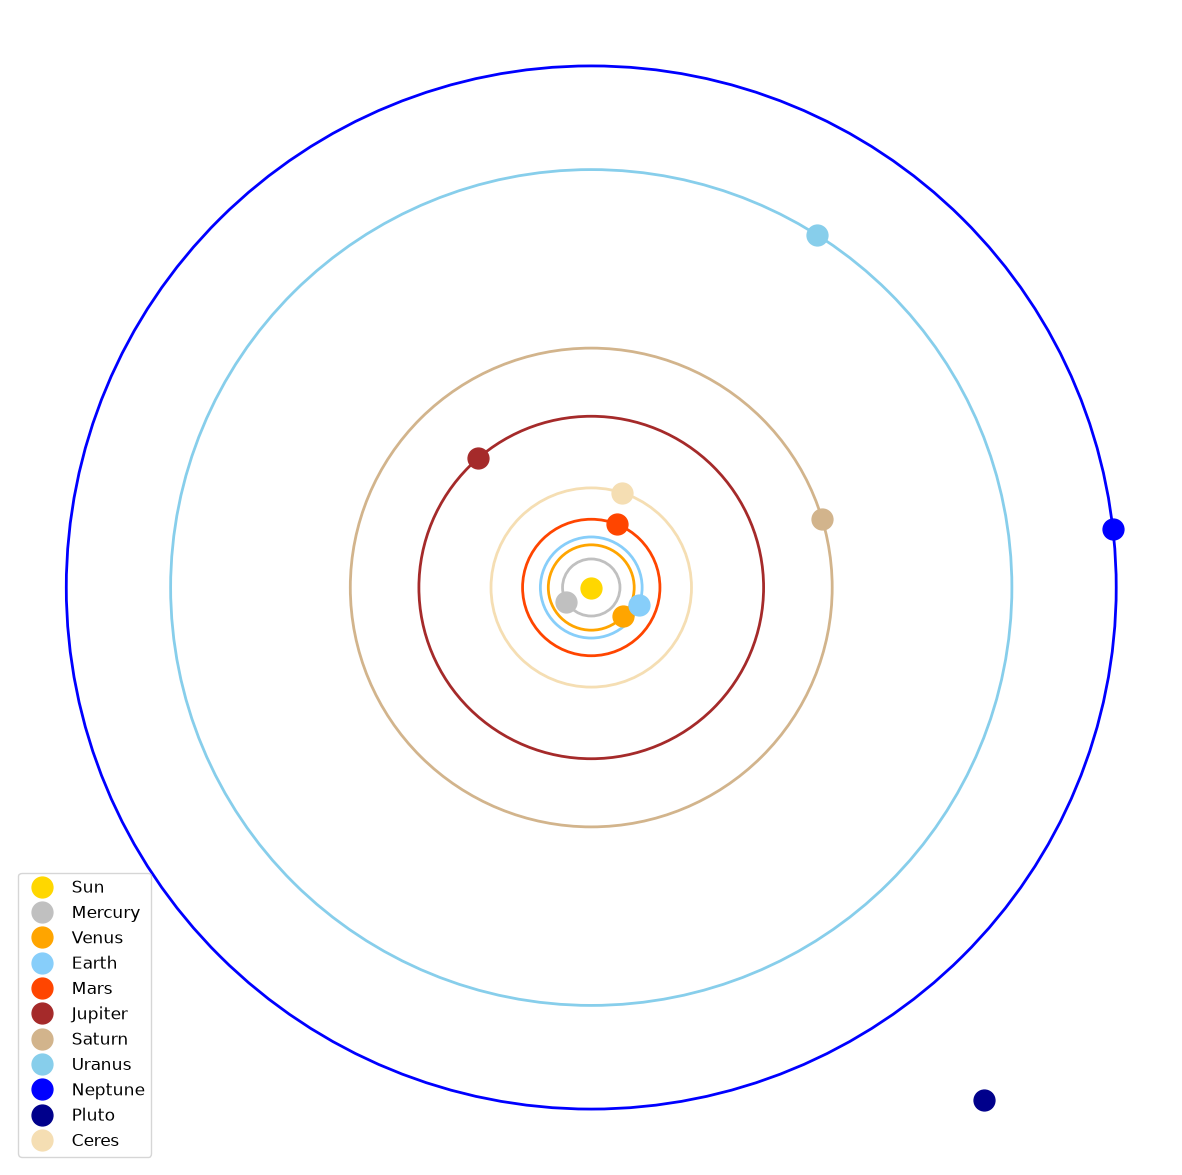

In [30]:
plt.figure(figsize=(15,15))
ax = plt.gca()
ax.cla() # clear things for fresh plot
# ax.set_xlim((-6, 6))
# ax.set_ylim((-6, 6))
ax.set_xlim((-12, 12))
ax.set_ylim((-12, 12))
a=0.5
ax.plot(0,0,'.', markersize=30, label='Sun', color=mcolors.CSS4_COLORS['gold']) 
for i in range(10):
    ax.plot(forplot[i][0] , forplot[i][1] ,'.', markersize=30, label=planetname[i], 
            color=mcolors.CSS4_COLORS[planet_colors[planetname[i]]]) 
#     if (i >1) & (i < 10):
#     if  (i < 11):
    if  (i < 8)|(i>8):
#         circle = Circle(xy=(2, 3), radius=0.5)#, color='blue')
        ax.add_artist(plt.Circle((0, 0), ((abs(forplot[i][0])**2+abs(forplot[i][1])**2)**0.5), color=mcolors.CSS4_COLORS[planet_colors[planetname[i]]],#color='r', 
#         ax.add_artist(plt.Circle((0, 0), ((abs(forplot[i][0])**2+abs(forplot[i][1])**2)**0.5), radius=0.5, 
                             linewidth=2,    fill=False))
ax.legend(fontsize=12, loc='lower left')
# plt.yticks(fontsize=14)
# plt.xticks(fontsize=14)
plt.axis('off')
# Save as high-res PNG
plt.savefig('Solar_System_Live.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [ ]:
Geq = helio_solarsystem.Geocentric(year=year, month=month, day=day, hour=hour, minute=minute, 
                         UT=UT, dst=dst, plane='equatorial', precession=True)
Geqp=Geq.position()


print('Object','    \t','Right Ascension','\t','Declination','\t','Distace in AU')
print('-----------------------------------------------------------------------')
for i in Geqp:
    print(i,'    \t',helio_solarsystem.demical2hms(Geqp[i][0]),'      \t',
          helio_solarsystem.demical2arcs(Geqp[i][1]),'\t',round(Geqp[i][2],2))
    

Object     	 Right Ascension 	 Declination 	 Distace in AU
-----------------------------------------------------------------------
Sun     	 11h 10m 14s       	 5° 20.11' 	 1.01
Mercury     	 11h 52m 45s       	 1° 43.23' 	 1.36
Venus     	 13h 41m 32s       	 -15° 20.57' 	 0.49
Mars     	 7h 19m 58s       	 22° 50.07' 	 1.8
Jupiter     	 9h 10m 53s       	 16° 49.74' 	 6.13
Saturn     	 0h 51m 6s       	 2° 34.48' 	 8.55
Uranus     	 4h 13m 48s       	 21° 2.32' 	 19.21
Neptune     	 0h 13m 30s       	 0° 4.82' 	 28.9
Pluto     	 20h 25m 25s       	 -23° 40.07' 	 34.81
Ceres     	 6h 40m 0s       	 22° 57.11' 	 2.91
Chiron     	 1h 48m 55s       	 11° 26.03' 	 17.48
Eris     	 1h 47m 19s       	 0° 10.77' 	 94.66


In [ ]:
# Not applying the correction for the earth axial rotation, precession=False
Geq = helio_solarsystem.Geocentric(year=year, month=month, day=day, hour=hour, minute=minute, 
                         UT=UT, dst=dst, plane='equatorial', precession=False)
Geqp=Geq.position()


print('Object','    \t','Right Ascension','\t','Declination','\t','Distace in AU')
print('-----------------------------------------------------------------------')
for i in Geqp:
    print(i,'    \t',helio_solarsystem.demical2hms(Geqp[i][0]),'      \t',
          helio_solarsystem.demical2arcs(Geqp[i][1]),'\t',round(Geqp[i][2],2))
    

Object     	 Right Ascension 	 Declination 	 Distace in AU
-----------------------------------------------------------------------
Sun     	 11h 11m 36s       	 5° 11.42' 	 1.01
Mercury     	 11h 54m 7s       	 1° 34.34' 	 1.36
Venus     	 13h 42m 58s       	 -15° 28.6' 	 0.49
Mars     	 7h 21m 35s       	 22° 47.0' 	 1.8
Jupiter     	 9h 12m 23s       	 16° 43.13' 	 6.13
Saturn     	 0h 52m 29s       	 2° 43.15' 	 8.55
Uranus     	 4h 15m 22s       	 21° 6.27' 	 19.21
Neptune     	 0h 14m 52s       	 0° 4.06' 	 28.9
Pluto     	 20h 27m 0s       	 -23° 34.77' 	 34.81
Ceres     	 6h 42m 10s       	 22° 54.99' 	 2.91
Chiron     	 1h 51m 4s       	 11° 38.02' 	 17.48
Eris     	 1h 49m 22s       	 0° 1.14' 	 94.66


In [ ]:
# Greenwich, England Coordinates
longtitude = 0
latitude   = 51.5

moon = helio_solarsystem.Moon(year=year, month=month, day=day, hour=hour, minute=minute, 
                         UT=UT, dst=dst, longtitude=longtitude, latitude=latitude, topographic=True)
moon_position = moon.position()

In [34]:
moon_position

(145.9313073724013, -0.21610765193642512, 58.26566766862974)

In [ ]:
moon_position_eq=helio_solarsystem.spherical_ecliptic2equatorial(moon_position[0],moon_position[1],moon_position[2],H.oblecl)

In [36]:
moon_position_eq

(148.10688761506935, 12.670040339418168, 58.26566766862973)

In [ ]:
print('Object','\t','Right Ascension','\t','Declination','\t','Distace in Earth Radius')
print('Moon','\t',helio_solarsystem.demical2hms(moon_position_eq[0]),'     \t',
      helio_solarsystem.demical2arcs(moon_position_eq[1]) ,'\t',moon_position_eq[2])

Object 	 Right Ascension 	 Declination 	 Distace in Earth Radius
Moon 	 9h 52m 25s      	 12° 40.2' 	 58.26566766862973
